In [ ]:
%pip install matplotlib

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

import joblib

In [2]:
model = joblib.load('models/churn_model_GB.joblib')
model_type = "gb"
drift_results = []

In [21]:
for i in range(20):

    batch_data = pd.read_csv(f'data/streaming/batch_{i:03d}.csv')

    features = [
    'account_age','total_purchases', 'avg_purchase_value',
    'days_since_purchase', 'login_weekly_frequency',
    'complaints_raised','avg_product_rating_5','email_open_rate'
    ]

    X = batch_data[features]
    y = batch_data['churned']

    if model_type == 'logreg':
        scaler = joblib.load('models/scaler_v1.joblib')
        X = scaler.transform(X)
    
    y_pred = model.predict(X)
    y_pred_prob = model.predict_proba(X)

    results = {
        'batch_id' : i,
        'drift_magnitude': batch_data['drift_magnitude'][0],
        'accuracy_score': accuracy_score(y, y_pred),
        'precision_score': precision_score(y, y_pred),
        'recall_score': recall_score(y, y_pred),
        'f1_score': f1_score(y, y_pred),
        'roc_auc_score': roc_auc_score(y, y_pred_prob[:, 1])
    }

    if i ==0:
        
        print(f"DIAGNOSTIC FOR BATCH {i}")
        print("Actual churn rate:", y.mean())
        print("Predicted churn rate:", y_pred.mean())   

    # drift_results.append(results)
    print(f"Batch #{i:03d} with drift={results['drift_magnitude']:.3f}: Accuracy={results['accuracy_score']:.3f}, Precision={results['precision_score']:.3f}, Recall={results['recall_score']:.3f}")


DIAGNOSTIC FOR BATCH 0
Actual churn rate: 0.26
Predicted churn rate: 0.27
Batch #000 with drift=0.000: Accuracy=0.970, Precision=0.926, Recall=0.962
Batch #001 with drift=0.000: Accuracy=0.950, Precision=0.853, Recall=1.000
Batch #002 with drift=0.000: Accuracy=0.920, Precision=0.920, Recall=0.793
Batch #003 with drift=0.000: Accuracy=0.950, Precision=0.935, Recall=0.906
Batch #004 with drift=0.000: Accuracy=0.930, Precision=0.897, Recall=0.867
Batch #005 with drift=0.000: Accuracy=0.950, Precision=0.912, Recall=0.939
Batch #006 with drift=0.047: Accuracy=0.960, Precision=0.949, Recall=0.949
Batch #007 with drift=0.093: Accuracy=0.920, Precision=0.824, Recall=0.933
Batch #008 with drift=0.140: Accuracy=0.940, Precision=0.872, Recall=0.971
Batch #009 with drift=0.187: Accuracy=0.930, Precision=0.846, Recall=0.971
Batch #010 with drift=0.233: Accuracy=0.830, Precision=0.641, Recall=0.893
Batch #011 with drift=0.280: Accuracy=0.860, Precision=0.729, Recall=0.972
Batch #012 with drift=0.32

In [4]:
drift_results = pd.DataFrame(drift_results)
drift_results.to_csv('drift_stream_results.csv')

In [6]:
len(drift_results)

20

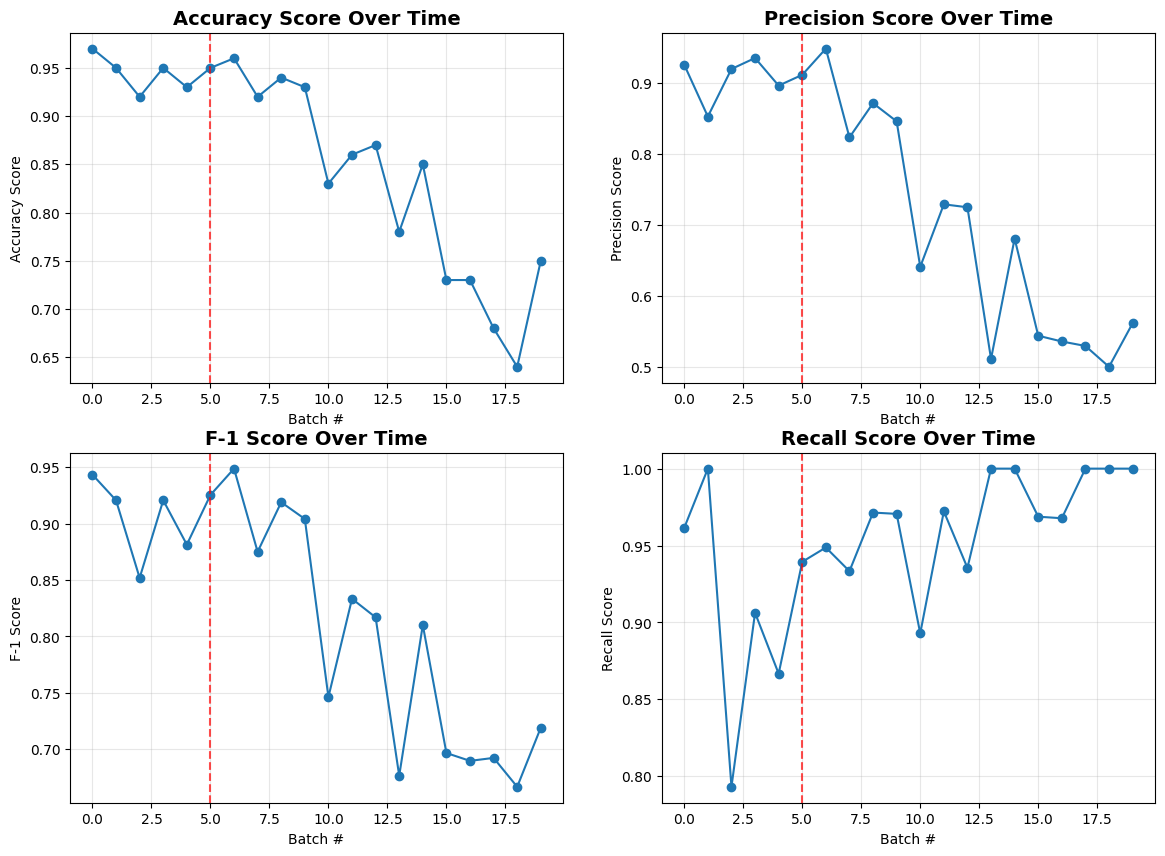

In [20]:
fig,axes = plt.subplots(2,2,figsize=(14,10))
axes[0,0].plot(drift_results['batch_id'], drift_results['accuracy_score'], marker='o')
axes[0,0].axvline(x=5, color='red', linestyle='--', label='Drift Starts', alpha=0.7)
axes[0,0].set_title('Accuracy Score Over Time', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel("Accuracy Score")
axes[0,0].set_xlabel("Batch #")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(drift_results['batch_id'], drift_results['precision_score'], marker='o')
axes[0,1].axvline(x=5, color='red', linestyle='--', label='Drift Starts', alpha=0.7)
axes[0,1].set_title('Precision Score Over Time', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel("Precision Score")
axes[0,1].set_xlabel("Batch #")
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(drift_results['batch_id'], drift_results['f1_score'], marker='o')
axes[1,0].axvline(x=5, color='red', linestyle='--', label='Drift Starts', alpha=0.7)
axes[1,0].set_title('F-1 Score Over Time', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel("F-1 Score")
axes[1,0].set_xlabel("Batch #")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(drift_results['batch_id'], drift_results['recall_score'], marker='o')
axes[1,1].axvline(x=5, color='red', linestyle='--', label='Drift Starts', alpha=0.7)
axes[1,1].set_title('Recall Score Over Time', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel("Recall Score")
axes[1,1].set_xlabel("Batch #")
axes[1,1].grid(True, alpha=0.3)

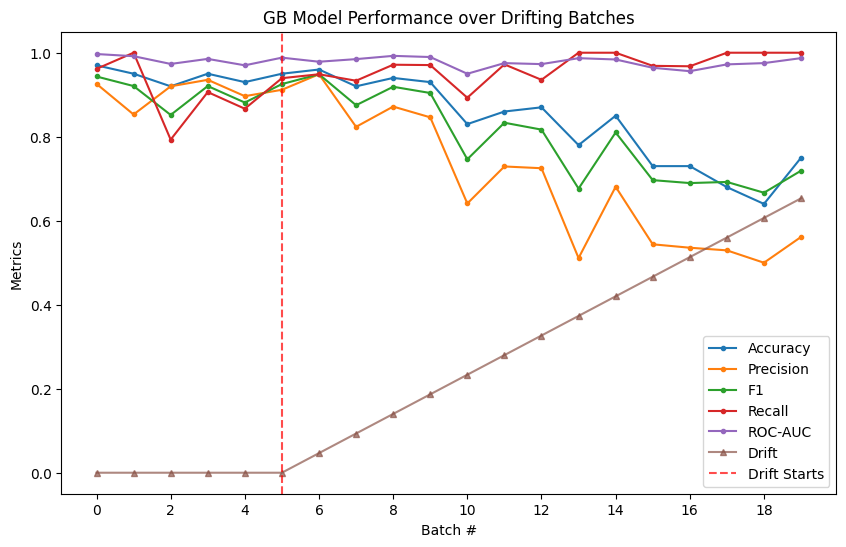

In [41]:
plt.figure(figsize=(10, 6)) 
plt.plot(drift_results['batch_id'], drift_results['accuracy_score'], label="Accuracy", marker='.')
plt.plot(drift_results['batch_id'], drift_results['precision_score'], label="Precision", marker='.')
plt.plot(drift_results['batch_id'], drift_results['f1_score'], label="F1", marker='.')
plt.plot(drift_results['batch_id'], drift_results['recall_score'], label="Recall", marker='.')
plt.plot(drift_results['batch_id'], drift_results['roc_auc_score'], label="ROC-AUC", marker='.')
plt.plot(drift_results['batch_id'], drift_results['drift_magnitude'], label="Drift", marker='^', markersize=4,alpha=0.7)
plt.axvline(x=5, color='red', linestyle='--', label='Drift Starts', alpha=0.7)
plt.xticks(np.arange(0, 20, 2))
plt.title("GB Model Performance over Drifting Batches")
plt.ylabel("Metrics")
plt.xlabel("Batch #")
plt.legend()